RF Accuracy: 0.7166264116456688
              precision    recall  f1-score   support

           0       0.93      0.71      0.81     38012
           1       0.35      0.75      0.48      7945

    accuracy                           0.72     45957
   macro avg       0.64      0.73      0.64     45957
weighted avg       0.83      0.72      0.75     45957

RF ROC AUC: 0.8049417139445283
XGB Accuracy: 0.5989076745653545
              precision    recall  f1-score   support

           0       0.96      0.54      0.69     38012
           1       0.29      0.90      0.44      7945

    accuracy                           0.60     45957
   macro avg       0.62      0.72      0.56     45957
weighted avg       0.84      0.60      0.65     45957

XGB ROC AUC: 0.8128385180209066
RF CV F1: 0.9369431736515192
                   Feature  Importance
13                 GenHlth    0.192372
24             Cardio_Risk    0.100645
23       Health_Risk_Score    0.096204
18                     Age    0.0

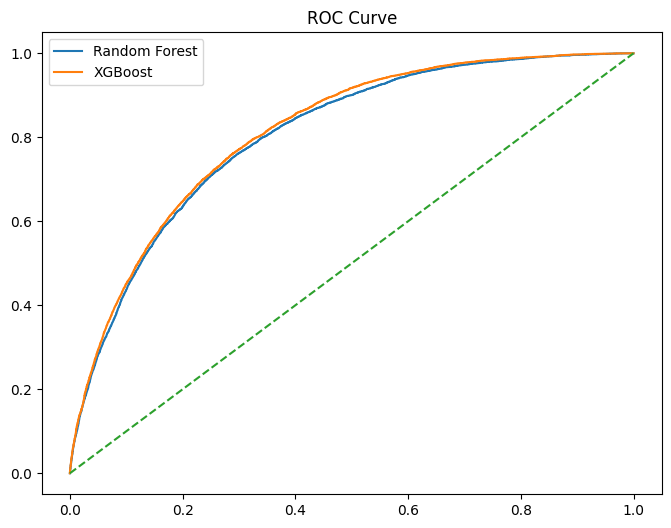

In [ ]:
# Diabetes Prediction Project - Optimized Version

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score
)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.combine import SMOTEENN

# Load Data
url = "https://drive.google.com/uc?export=download&id=1KM7-w5Zw6yPguF25fk_ois0CM_G30DQ9"
df = pd.read_csv(url)

# Cleaning
df = df.drop_duplicates().reset_index(drop=True)

# Feature Engineering
def bmi_category(bmi):
    if bmi < 18.5: return 0
    elif bmi < 25: return 1
    elif bmi < 30: return 2
    return 3

def age_category(age):
    if age <= 4: return 0
    elif age <= 8: return 1
    return 2

df["BMI_cat"] = df["BMI"].apply(bmi_category)
df["Age_cat"] = df["Age"].apply(age_category)

df["Health_Risk_Score"] = (
    df["HighBP"] + df["HighChol"] +
    df["HeartDiseaseorAttack"] + df["Stroke"]
)

df["Cardio_Risk"] = (
    df["HighBP"] + df["HighChol"] +
    df["HeartDiseaseorAttack"] + df["Stroke"]
)

df["Lifestyle_Risk"] = (
    df["Smoker"] + df["HvyAlcoholConsump"] +
    (1 - df["PhysActivity"])
)

df["Physical_Health_Burden"] = (
    df["PhysHlth"] + df["MentHlth"]
)

df["Healthcare_Barrier"] = (
    df["NoDocbcCost"] + (1 - df["AnyHealthcare"])
)

df["BMI_Activity"] = df["BMI"] * df["PhysActivity"]

df["Diabetes_Binary"] = df["Diabetes_012"].map({0:0,1:1,2:1})
df.drop(columns=["Diabetes_012"], inplace=True)

# Split
X = df.drop("Diabetes_Binary", axis=1)
y = df["Diabetes_Binary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balance
smoteenn = SMOTEENN(random_state=42)
X_train_res, y_train_res = smoteenn.fit_resample(
    X_train_scaled, y_train
)

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced_subsample",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_res, y_train_res)

rf_prob = rf_model.predict_proba(X_test_scaled)[:,1]
rf_pred = (rf_prob > 0.35).astype(int)

print("RF Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))
print("RF ROC AUC:", roc_auc_score(y_test, rf_prob))

# XGBoost
neg = y_train.value_counts()[0]
pos = y_train.value_counts()[1]

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=neg/pos,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_res, y_train_res)

xgb_prob = xgb_model.predict_proba(X_test_scaled)[:,1]
xgb_pred = (xgb_prob > 0.35).astype(int)

print("XGB Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred))
print("XGB ROC AUC:", roc_auc_score(y_test, xgb_prob))

# Cross Validation
cv_scores = cross_val_score(
    rf_model,
    X_train_res,
    y_train_res,
    cv=5,
    scoring="f1"
)

print("RF CV F1:", cv_scores.mean())

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(15))

# ROC Curve
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot(xgb_fpr, xgb_tpr, label="XGBoost")
plt.plot([0,1],[0,1],"--")
plt.legend()
plt.title("ROC Curve")
plt.show()
